# Making a color map between JWST F200W filter and HST F814W filter

This with the goal of seeing the the disk at the center that we observe in the residuals of the MGE fits is a result of a gradient in the populations present there.

In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval
from astropy import units as u
# import reproject functions
from reproject import reproject_interp


## Downsample the JWST data to hubble and set them in the same frame

In [30]:
# load the HST and JWST images
hst_mosaic =  fits.open(
        '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/HST/MAST_2026-03-10T1856/HST/u2j20e07t/u2j20e07t_drw.fits'
    )
jwst_mosaic = fits.open(
        '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200w_ifu_coadd_NOAGN_aligned.fits'
    )

In [38]:
# move the HST CRVAL1 and CRVAL2 to the center of the image, which is where the JWST image is centered
print(f"Original HST CRVAL1: {hst_mosaic[1].header['CRVAL1']}")
print(f"Original HST CRVAL2: {hst_mosaic[1].header['CRVAL2']}")
hst_mosaic[1].header['CRVAL1'] = hst_mosaic[1].header['CRVAL1'] + 10.5/3600
hst_mosaic[1].header['CRVAL2'] = hst_mosaic[1].header['CRVAL2'] - 1.5/3600

Original HST CRVAL1: 190.00719364595193
Original HST CRVAL2: -11.626281004167847


In [39]:
# reproject the JWST image to the HST WCS
jwst_reprojected, footprint = reproject_interp(jwst_mosaic[0], hst_mosaic[1].header)

# Scale the fluxes

We know from the flux of the MGE that for the HST to match the JWST data we need a scaling

HST -> JWST scale factor: 1723.492813859184
JWST annulus flux: 167024907.4957221
HST annulus flux (unscaled): 96910.70722930711

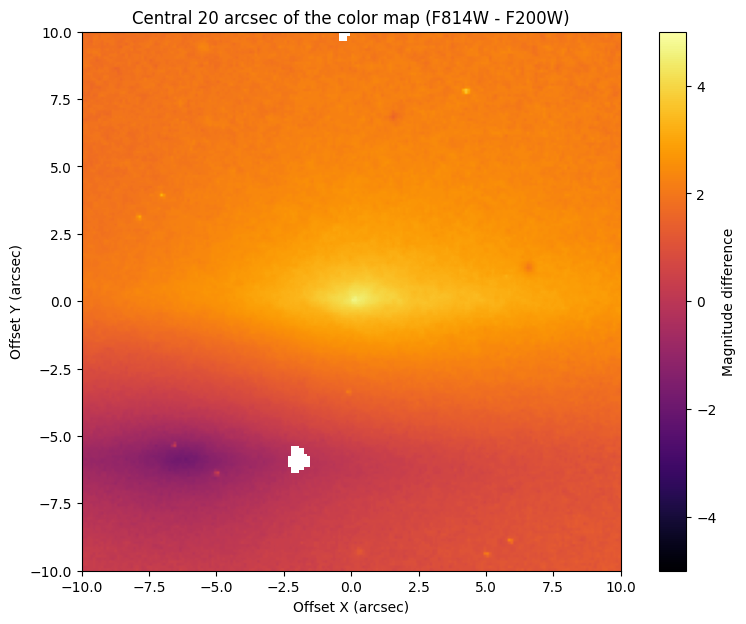

/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_97582/2040448182.py:25: UserWarning: Adding colorbar to a different Figure <Figure size 1000x700 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=ax)


<Figure size 640x480 with 0 Axes>

In [41]:
hst_to_jwst_scale_factor =  1723.492813859184
# using a pixel scale of 0.1 arcsec/pixel plot the central 20 arcsec of the color map, which corresponds to 200 pixels on each side of the center
center_x, center_y = (2720.5, 2392.85) # center of the image in pixels
pixel_scale = 0.1 # arcsec/pixel
half_size = 100  # pixels, corresponding to 10 arcsec

# crop the color map to the central region
cx, cy = int(center_x), int(center_y)
color_map_crop = color_map[cy - half_size:cy + half_size, cx - half_size:cx + half_size]

# define extent in arcsec relative to center
extent_arcsec = [-half_size * pixel_scale, half_size * pixel_scale,
				 -half_size * pixel_scale, half_size * pixel_scale]

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(color_map_crop, origin='lower', cmap='inferno', vmin=-5, vmax=5, extent=extent_arcsec)
ax.set_title('Central 20 arcsec of the color map (F814W - F200W)')
ax.set_xlabel('Offset X (arcsec)')
ax.set_ylabel('Offset Y (arcsec)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Magnitude difference')
plt.show()
ax.set_xlabel('Offset X (arcsec)')
ax.set_ylabel('Offset Y (arcsec)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Magnitude difference')
plt.show()

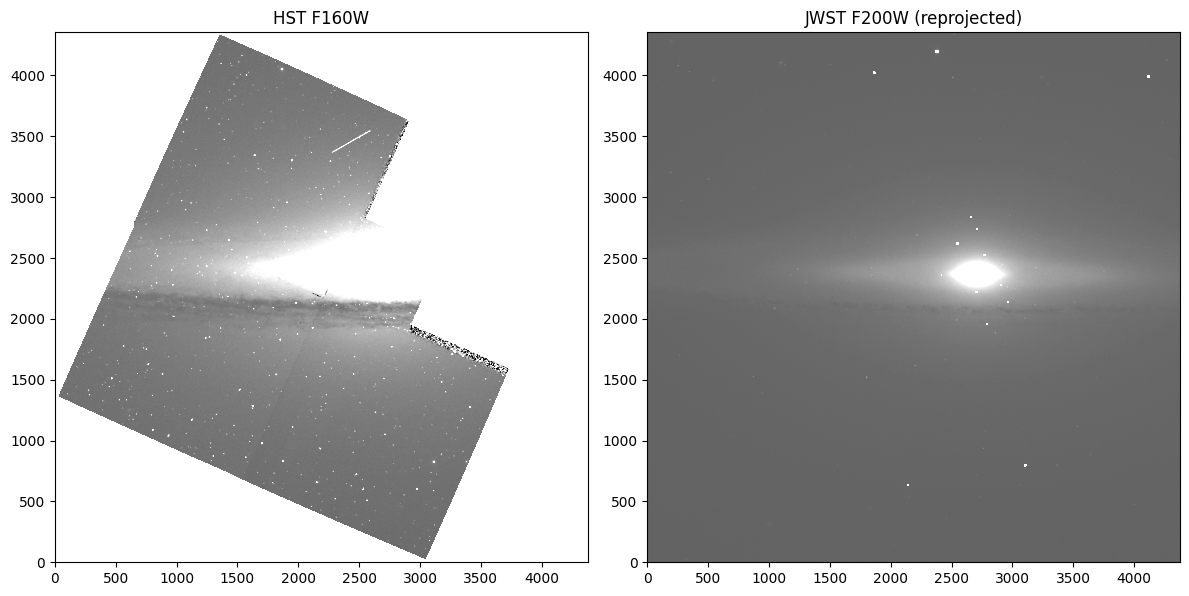

In [11]:
hst_to_jwst_scale_factor =  1723.492813859184

# plot the two images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(hst_mosaic[1].data*hst_to_jwst_scale_factor)
axes[0].imshow(hst_mosaic[1].data*hst_to_jwst_scale_factor, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('HST F160W')
axes[1].imshow(jwst_reprojected, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title('JWST F200W (reprojected)')
plt.tight_layout()
plt.show()

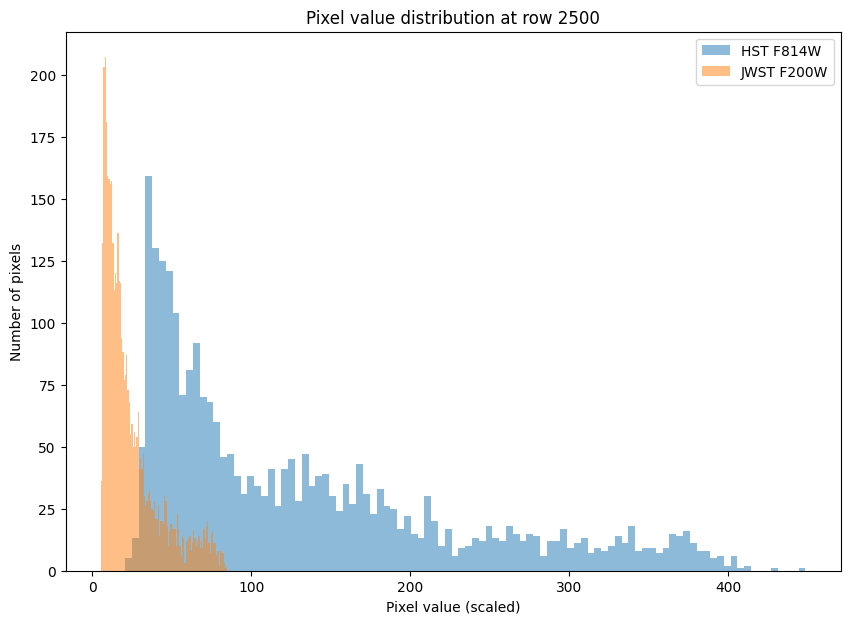

In [14]:
# plot the histogram of the pixel values in both images at the same scale, using a cut at row 2500
fig, ax = plt.subplots(figsize=(10, 7))
ax.hist(hst_mosaic[1].data[2500, :]*hst_to_jwst_scale_factor, bins=100, alpha=0.5, label='HST F814W')
ax.hist(jwst_reprojected[2500, :], bins=100, alpha=0.5, label='JWST F200W')
ax.set_xlabel('Pixel value (scaled)')
ax.set_ylabel('Number of pixels')
ax.set_title('Pixel value distribution at row 2500')
ax.legend()
plt.show()

# Make color map of F814W - F200W

/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_97582/3890732458.py:2: RuntimeWarning: invalid value encountered in log10
  color_map = -2.5 * np.log10(jwst_reprojected / (hst_mosaic[1].data*hst_to_jwst_scale_factor))


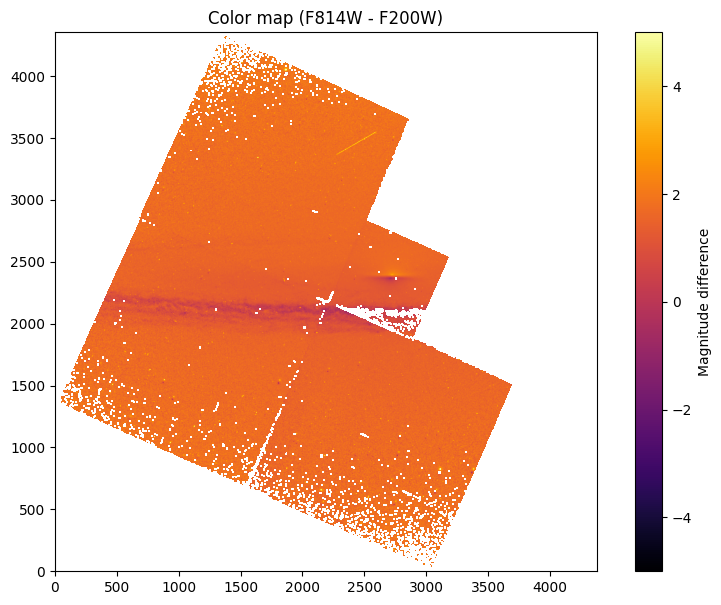

In [21]:
# make color map of F814W - F200W, note that the images are already aligned and on the same WCS, so we can just subtract them and plot the result in magnitudes
color_map = -2.5 * np.log10(jwst_reprojected / (hst_mosaic[1].data*hst_to_jwst_scale_factor))
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(color_map, origin='lower', cmap='inferno', vmin=-5, vmax=5)
ax.set_title('Color map (F814W - F200W)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Magnitude difference')
plt.show()

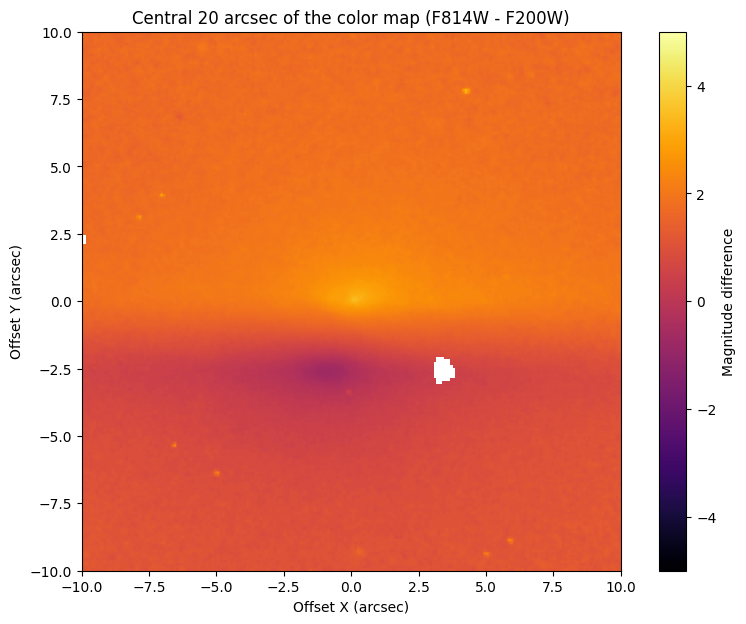

/var/folders/__/n140hqf972zfmtt1hs5ldglw0000gn/T/ipykernel_97582/3496005284.py:24: UserWarning: Adding colorbar to a different Figure <Figure size 1000x700 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(im, ax=ax)


<Figure size 640x480 with 0 Axes>

In [25]:
# using a pixel scale of 0.1 arcsec/pixel plot the central 20 arcsec of the color map, which corresponds to 200 pixels on each side of the center
center_x, center_y = (2720.5, 2392.85) # center of the image in pixels
pixel_scale = 0.1 # arcsec/pixel
half_size = 100  # pixels, corresponding to 10 arcsec

# crop the color map to the central region
cx, cy = int(center_x), int(center_y)
color_map_crop = color_map[cy - half_size:cy + half_size, cx - half_size:cx + half_size]

# define extent in arcsec relative to center
extent_arcsec = [-half_size * pixel_scale, half_size * pixel_scale,
				 -half_size * pixel_scale, half_size * pixel_scale]

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(color_map_crop, origin='lower', cmap='inferno', vmin=-5, vmax=5, extent=extent_arcsec)
ax.set_title('Central 20 arcsec of the color map (F814W - F200W)')
ax.set_xlabel('Offset X (arcsec)')
ax.set_ylabel('Offset Y (arcsec)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Magnitude difference')
plt.show()
ax.set_xlabel('Offset X (arcsec)')
ax.set_ylabel('Offset Y (arcsec)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Magnitude difference')
plt.show()

# Align the two images